In [ ]:
# EXPERIMENT 1
# Data Loading, Cleaning and Exploratory Data Analysis

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [ ]:
# ---------------------------------------------------------
# 1. Read the dataset
# ---------------------------------------------------------

file_path = input("Enter the CSV file path: ")

try:
    df = pd.read_csv(file_path)
except FileNotFoundError:
    print("File not found. Please check the file path.")
    exit()


print("\n========== DATASET ==========")
print(df)

Enter the CSV file path: /content/ElectricCarData_Norm.csv

========== DATASET ==========
           Brand                            Model     Accel  TopSpeed   Range  \
0         Tesla     Model 3 Long Range Dual Motor   4.6 sec  233 km/h  450 km   
1    Volkswagen                         ID.3 Pure  10.0 sec  160 km/h  270 km   
2      Polestar                                 2   4.7 sec  210 km/h  400 km   
3           BMW                              iX3    6.8 sec  180 km/h  360 km   
4         Honda                                e    9.5 sec  145 km/h  170 km   
..           ...                              ...       ...       ...     ...   
98       Nissan                       Ariya 63kWh   7.5 sec  160 km/h  330 km   
99         Audi     e-tron S Sportback 55 quattro   4.5 sec  210 km/h  335 km   
100      Nissan               Ariya e-4ORCE 63kWh   5.9 sec  200 km/h  325 km   
101      Nissan   Ariya e-4ORCE 87kWh Performance   5.1 sec  200 km/h  375 km   
102       Byton    

In [ ]:
# ---------------------------------------------------------
# 2. Basic information
# ---------------------------------------------------------

print("\n========== DATASET SHAPE ==========")
print("Rows    :", df.shape[0])
print("Columns :", df.shape[1])


print("\n========== DATA TYPES ==========")
print(df.dtypes)


print("\n========== FIRST 5 ROWS ==========")
print(df.head())


========== DATASET SHAPE ==========
Rows    : 103
Columns : 14

========== DATA TYPES ==========
Brand          object
Model          object
Accel          object
TopSpeed       object
Range          object
Efficiency     object
FastCharge     object
RapidCharge    object
PowerTrain     object
PlugType       object
BodyStyle      object
Segment        object
Seats           int64
PriceEuro       int64
dtype: object

========== FIRST 5 ROWS ==========
         Brand                          Model     Accel  TopSpeed   Range  \
0       Tesla   Model 3 Long Range Dual Motor   4.6 sec  233 km/h  450 km   
1  Volkswagen                       ID.3 Pure  10.0 sec  160 km/h  270 km   
2    Polestar                               2   4.7 sec  210 km/h  400 km   
3         BMW                            iX3    6.8 sec  180 km/h  360 km   
4       Honda                              e    9.5 sec  145 km/h  170 km   

  Efficiency FastCharge              RapidCharge        PowerTrain  \
0  161 Wh/k

In [ ]:
# ---------------------------------------------------------
# 3. Check missing values
# ---------------------------------------------------------

print("\n========== MISSING VALUES ==========")
print(df.isnull().sum())


========== MISSING VALUES ==========
Brand          0
Model          0
Accel          0
TopSpeed       0
Range          0
Efficiency     0
FastCharge     0
RapidCharge    0
PowerTrain     0
PlugType       0
BodyStyle      0
Segment        0
Seats          0
PriceEuro      0
dtype: int64


In [ ]:
# ---------------------------------------------------------
# 4. Handle missing values
# ---------------------------------------------------------

numeric_columns = df.select_dtypes(include=np.number).columns
categorical_columns = df.select_dtypes(exclude=np.number).columns


# Fill numerical missing values with mean
for column in numeric_columns:
    df[column] = df[column].fillna(df[column].mean())


# Fill categorical missing values with mode
for column in categorical_columns:
    if df[column].isnull().sum() > 0:
        df[column] = df[column].fillna(df[column].mode()[0])


print("\n========== AFTER CLEANING ==========")
print(df.isnull().sum())


========== AFTER CLEANING ==========
Brand          0
Model          0
Accel          0
TopSpeed       0
Range          0
Efficiency     0
FastCharge     0
RapidCharge    0
PowerTrain     0
PlugType       0
BodyStyle      0
Segment        0
Seats          0
PriceEuro      0
dtype: int64


In [ ]:
# ---------------------------------------------------------
# 5. Summary statistics
# ---------------------------------------------------------

print("\n========== SUMMARY STATISTICS ==========")
print(df.describe(include="all"))


========== SUMMARY STATISTICS ==========
         Brand          Model    Accel  TopSpeed   Range Efficiency  \
count      103            103      103       103     103        103   
unique      33            102       55        25      50         54   
top     Tesla   e-Soul 64 kWh  9.0 sec  160 km/h  250 km  168 Wh/km   
freq        13              2        7        15       6          6   
mean       NaN            NaN      NaN       NaN     NaN        NaN   
std        NaN            NaN      NaN       NaN     NaN        NaN   
min        NaN            NaN      NaN       NaN     NaN        NaN   
25%        NaN            NaN      NaN       NaN     NaN        NaN   
50%        NaN            NaN      NaN       NaN     NaN        NaN   
75%        NaN            NaN      NaN       NaN     NaN        NaN   
max        NaN            NaN      NaN       NaN     NaN        NaN   

       FastCharge              RapidCharge       PowerTrain    PlugType  \
count         103             

In [ ]:
# ---------------------------------------------------------
# 6. Numerical data analysis
# ---------------------------------------------------------

if len(numeric_columns) > 0:

    print("\n========== NUMERICAL SUMMARY ==========")

    for column in numeric_columns:
        print("\nColumn:", column)
        print("Mean   :", np.mean(df[column]))
        print("Median :", np.median(df[column]))
        print("Std    :", np.std(df[column]))


========== NUMERICAL SUMMARY ==========

Column: Seats
Mean   : 4.883495145631068
Median : 5.0
Std    : 0.7919616896906065

Column: PriceEuro
Mean   : 55811.563106796115
Median : 45000.0
Std    : 33968.5588673934


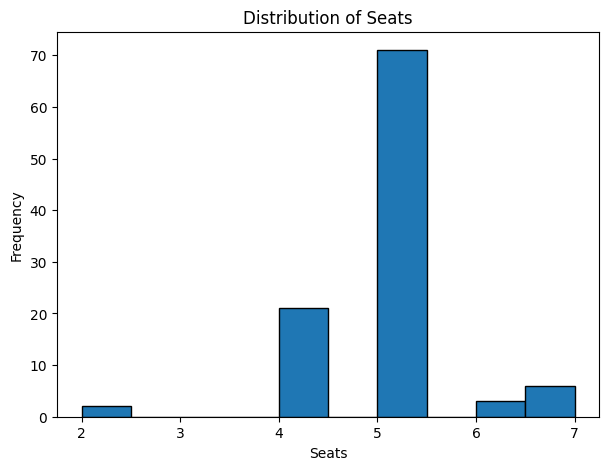

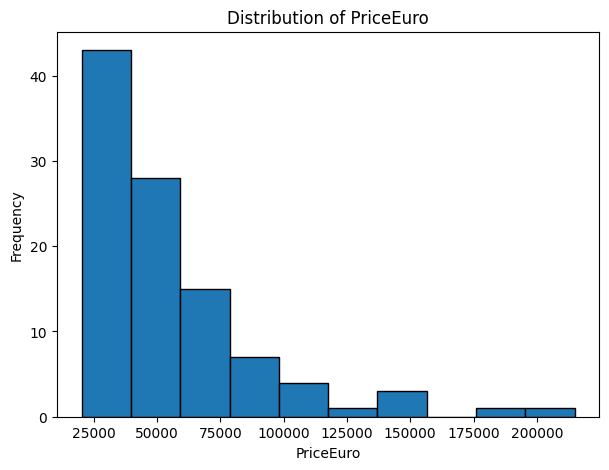

In [ ]:
# ---------------------------------------------------------
# 7. Distribution plots
# ---------------------------------------------------------

for column in numeric_columns:

    plt.figure(figsize=(7, 5))

    plt.hist(df[column], bins=10, edgecolor="black")

    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")

    plt.show()


========== CORRELATION MATRIX ==========
             Seats  PriceEuro
Seats      1.00000    0.02092
PriceEuro  0.02092    1.00000


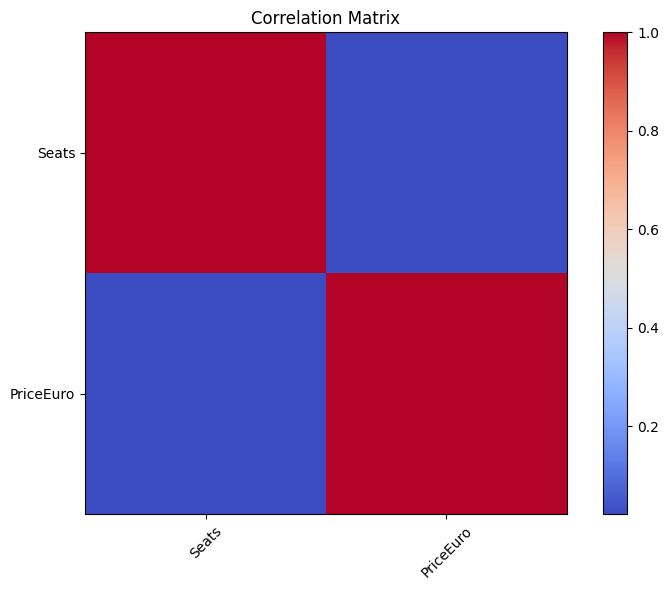


EDA completed successfully.


In [ ]:
# ---------------------------------------------------------
# 8. Correlation matrix
# ---------------------------------------------------------

if len(numeric_columns) >= 2:

    correlation = df[numeric_columns].corr()

    print("\n========== CORRELATION MATRIX ==========")
    print(correlation)


    # Plot correlation matrix

    plt.figure(figsize=(8, 6))

    plt.imshow(correlation, cmap="coolwarm", interpolation="none")

    plt.colorbar()

    plt.xticks(
        range(len(correlation.columns)),
        correlation.columns,
        rotation=45
    )

    plt.yticks(
        range(len(correlation.columns)),
        correlation.columns
    )

    plt.title("Correlation Matrix")

    plt.tight_layout()
    plt.show()


print("\nEDA completed successfully.")